# Box-Behnken example with synthetic data
## Foundations of Box-Behnken Design (BBD)
Box-Behnken Design (BBD) is a type of Response Surface Methodology (RSM) used to model and optimize process variables. It is specifically engineered to fit a second-order (quadratic) polynomial model, making it ideal for understanding complex, non-linear relationships in bioprocessing (e.g., optimizing media composition, pH, and temperature for titer yield).\
Here are the foundational pillars of a Box-Behnken design:
1. **Geometry of the Design Space**\
Unlike Central Composite Designs (CCD) or Full Factorials, BBD does not have experimental points at the corners of the cube or outside the cubic space (axial points). Instead, treatment combinations are placed at the midpoints of the edges of the process space and at the center.
2. **Three Levels per Factor**\
BBD requires exactly three levels for each factor, coded as:
- -1 (Low level)
- 0 (Center point/Medium level)
- +1 (High level)
This allows the design to capture curvature in the response surface without requiring an excessive number of factor levels.\
3. **The "No Extremes" Advantage (Crucial for Bioprocessing)**\
Because BBD completely avoids the corners of the design space, it ensures that you never test a combination where all factors are simultaneously at their highest or lowest levels (e.g., maximum temperature, lowest pH, and highest dissolved oxygen).💡 Bioprocessing Impact: This prevents severe cell mortality or protein denaturation during screening, saving expensive runs from failing due to toxic combinatorial extremes.4. High EfficiencyBBD requires fewer experimental runs than a full factorial or central composite design as the number of factors ($k$) increases. The total number of runs ($N$) is calculated by the formula:$$N = 2k(k-1) + C_0$$(Where $k$ is the number of factors and $C_0$ is the number of center points).

### Tools used for designing:
**pyDOE3:**  https://pydoe3.readthedocs.io/en/latest/ \
**Info:**  https://www.theopeneducator.com/doe/Response-Surface-Methodology/Box-Behnken-Response-Surface-Methodology

In [2]:
# ==============================================================================
# Box-Behnken Design Modeling & Optimization
# ==============================================================================

import numpy as np
import pandas as pd
from pyDOE3 import bbdesign
import scipy.stats as stats
from scipy.optimize import minimize
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# 1. Initialize the Coded Box-Behnken Matrix (3 Factors, 3 Center Points)
# Yields 12 factorial edge runs + 3 center points = 15 runs
coded_matrix = bbdesign(3, center=3)
display(coded_matrix)
print(f'number of runs: {len(coded_matrix)}')

array([[-1., -1.,  0.],
       [-1.,  1.,  0.],
       [ 1., -1.,  0.],
       [ 1.,  1.,  0.],
       [-1.,  0., -1.],
       [-1.,  0.,  1.],
       [ 1.,  0., -1.],
       [ 1.,  0.,  1.],
       [ 0., -1., -1.],
       [ 0., -1.,  1.],
       [ 0.,  1., -1.],
       [ 0.,  1.,  1.],
       [ 0.,  0.,  0.],
       [ 0.,  0.,  0.],
       [ 0.,  0.,  0.]])

number of runs: 15


In [3]:
# 2. Convert to DataFrame and Assign Factor Labels
factor_names = ['X1', 'X2', 'X3']
df_bbd = pd.DataFrame(coded_matrix, columns=factor_names)
df_bbd

,X1,X2,X3
0,-1.0,-1.0,0.0
1,-1.0,1.0,0.0
2,1.0,-1.0,0.0
3,1.0,1.0,0.0
4,-1.0,0.0,-1.0
5,-1.0,0.0,1.0
6,1.0,0.0,-1.0
7,1.0,0.0,1.0
8,0.0,-1.0,-1.0
9,0.0,-1.0,1.0


In [4]:
# 3. Define the Explicit Operational Mapping Space
# Format: (Low (-1), High (+1))
factor_ranges = {
    'X1': (0.5, 1.5),
    'X2': (0.5, 1.5),
    'X3': (0.0, 1.0)
}
factor_ranges

{'X1': (0.5, 1.5), 'X2': (0.5, 1.5), 'X3': (0.0, 1.0)}

In [5]:
# 4. Map Coded Values (-1, 0, 1) to Real-World Process Metrics
df_experimental = df_bbd.copy()
for factor, (low, high) in factor_ranges.items():
    center = (low + high) / 2
    df_experimental[factor] = df_experimental[factor].map({-1: low, 0: center, 1: high})

df_experimental

,X1,X2,X3
0,0.5,0.5,0.5
1,0.5,1.5,0.5
2,1.5,0.5,0.5
3,1.5,1.5,0.5
4,0.5,1.0,0.0
5,0.5,1.0,1.0
6,1.5,1.0,0.0
7,1.5,1.0,1.0
8,1.0,0.5,0.0
9,1.0,0.5,1.0


In [6]:
# Adding the "scaled" values (-1, 0, +1) to the dataframe
for name in factor_names:
    df_experimental[name+'_scaled'] = df_bbd[name]
df_experimental

,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled
0,0.5,0.5,0.5,-1.0,-1.0,0.0
1,0.5,1.5,0.5,-1.0,1.0,0.0
2,1.5,0.5,0.5,1.0,-1.0,0.0
3,1.5,1.5,0.5,1.0,1.0,0.0
4,0.5,1.0,0.0,-1.0,0.0,-1.0
5,0.5,1.0,1.0,-1.0,0.0,1.0
6,1.5,1.0,0.0,1.0,0.0,-1.0
7,1.5,1.0,1.0,1.0,0.0,1.0
8,1.0,0.5,0.0,0.0,-1.0,-1.0
9,1.0,0.5,1.0,0.0,-1.0,1.0


In [7]:
# 6. Append Control Structures for Plate Map Uniformity
controls = pd.DataFrame([
    # 3 Baseline Controls (Standard Process Benchmarks)
    {'X1': 0.8, 'X2': 1.0, 'X3': 0.5, 'Type': 'Baseline_Control', 'Cell type': 'HEK293'},
    {'X1': 0.8, 'X2': 1.0, 'X3': 0.5, 'Type': 'Baseline_Control', 'Cell type': 'HEK293'},
    {'X1': 0.8, 'X2': 1.0, 'X3': 0.5, 'Type': 'Baseline_Control', 'Cell type': 'HEK293'},
    # 3 Negative Controls (Untransfected Cells)
    {'X1': 0.0, 'X2': 0.0, 'X3': 0.0, 'Type': 'Negative_Control', 'Cell type': 'HEK NS'},
    {'X1': 0.0, 'X2': 0.0, 'X3': 0.0, 'Type': 'Negative_Control', 'Cell type': 'HEK NS'},
    {'X1': 0.0, 'X2': 0.0, 'X3': 0.0, 'Type': 'Negative_Control', 'Cell type': 'HEK NS'},
    {'X1': 0.0, 'X2': 0.0, 'X3': 0.0, 'Type': 'Negative_Control', 'Cell type': 'HEK293'},
    {'X1': 0.0, 'X2': 0.0, 'X3': 0.0, 'Type': 'Negative_Control', 'Cell type': 'HEK293'},
    {'X1': 0.0, 'X2': 0.0, 'X3': 0.0, 'Type': 'Negative_Control', 'Cell type': 'HEK293'},
])

controls

,X1,X2,X3,Type,Cell type
0,0.8,1.0,0.5,Baseline_Control,HEK293
1,0.8,1.0,0.5,Baseline_Control,HEK293
2,0.8,1.0,0.5,Baseline_Control,HEK293
3,0.0,0.0,0.0,Negative_Control,HEK NS
4,0.0,0.0,0.0,Negative_Control,HEK NS
5,0.0,0.0,0.0,Negative_Control,HEK NS
6,0.0,0.0,0.0,Negative_Control,HEK293
7,0.0,0.0,0.0,Negative_Control,HEK293
8,0.0,0.0,0.0,Negative_Control,HEK293


In [8]:
# Add a type tag to experimental runs
df_experimental['Type'] = 'BBD_Run'
df_experimental['Cell type'] = 'HEK NS'
df_experimental

,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled,Type,Cell type
0,0.5,0.5,0.5,-1.0,-1.0,0.0,BBD_Run,HEK NS
1,0.5,1.5,0.5,-1.0,1.0,0.0,BBD_Run,HEK NS
2,1.5,0.5,0.5,1.0,-1.0,0.0,BBD_Run,HEK NS
3,1.5,1.5,0.5,1.0,1.0,0.0,BBD_Run,HEK NS
4,0.5,1.0,0.0,-1.0,0.0,-1.0,BBD_Run,HEK NS
5,0.5,1.0,1.0,-1.0,0.0,1.0,BBD_Run,HEK NS
6,1.5,1.0,0.0,1.0,0.0,-1.0,BBD_Run,HEK NS
7,1.5,1.0,1.0,1.0,0.0,1.0,BBD_Run,HEK NS
8,1.0,0.5,0.0,0.0,-1.0,-1.0,BBD_Run,HEK NS
9,1.0,0.5,1.0,0.0,-1.0,1.0,BBD_Run,HEK NS


In [9]:
# Combine into master 21-well layout sheet
master_plate_layout = pd.concat([df_experimental, controls], ignore_index=True)
master_plate_layout.index += 1
master_plate_layout.index.name = 'Well_ID'
master_plate_layout

,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled,Type,Cell type
Well_ID,,,,,,,,
1,0.5,0.5,0.5,-1.0,-1.0,0.0,BBD_Run,HEK NS
2,0.5,1.5,0.5,-1.0,1.0,0.0,BBD_Run,HEK NS
3,1.5,0.5,0.5,1.0,-1.0,0.0,BBD_Run,HEK NS
4,1.5,1.5,0.5,1.0,1.0,0.0,BBD_Run,HEK NS
5,0.5,1.0,0.0,-1.0,0.0,-1.0,BBD_Run,HEK NS
6,0.5,1.0,1.0,-1.0,0.0,1.0,BBD_Run,HEK NS
7,1.5,1.0,0.0,1.0,0.0,-1.0,BBD_Run,HEK NS
8,1.5,1.0,1.0,1.0,0.0,1.0,BBD_Run,HEK NS
9,1.0,0.5,0.0,0.0,-1.0,-1.0,BBD_Run,HEK NS


In [10]:
# Placeholder columns for analytical quantification tracking
for cqa in ['mAb_Titer', 'VCD', 'Viability']:
    master_plate_layout[cqa] = np.nan
master_plate_layout

,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled,Type,Cell type,mAb_Titer,VCD,Viability
Well_ID,,,,,,,,,,,
1,0.5,0.5,0.5,-1.0,-1.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
2,0.5,1.5,0.5,-1.0,1.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
3,1.5,0.5,0.5,1.0,-1.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
4,1.5,1.5,0.5,1.0,1.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
5,0.5,1.0,0.0,-1.0,0.0,-1.0,BBD_Run,HEK NS,NaN,NaN,NaN
6,0.5,1.0,1.0,-1.0,0.0,1.0,BBD_Run,HEK NS,NaN,NaN,NaN
7,1.5,1.0,0.0,1.0,0.0,-1.0,BBD_Run,HEK NS,NaN,NaN,NaN
8,1.5,1.0,1.0,1.0,0.0,1.0,BBD_Run,HEK NS,NaN,NaN,NaN
9,1.0,0.5,0.0,0.0,-1.0,-1.0,BBD_Run,HEK NS,NaN,NaN,NaN


In [11]:
# 5. Inject Statistical Randomization (Eliminates systematic block bias)
np.random.seed(42)  # Ensures reproducible randomization layout
master_plate_layout = master_plate_layout.sample(frac=1).reset_index(drop=True)
master_plate_layout

,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled,Type,Cell type,mAb_Titer,VCD,Viability
0,1.0,0.5,0.0,0.0,-1.0,-1.0,BBD_Run,HEK NS,NaN,NaN,NaN
1,0.8,1.0,0.5,NaN,NaN,NaN,Baseline_Control,HEK293,NaN,NaN,NaN
2,0.5,0.5,0.5,-1.0,-1.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
3,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK NS,NaN,NaN,NaN
4,1.0,1.5,1.0,0.0,1.0,1.0,BBD_Run,HEK NS,NaN,NaN,NaN
5,1.0,0.5,1.0,0.0,-1.0,1.0,BBD_Run,HEK NS,NaN,NaN,NaN
6,1.0,1.0,0.5,0.0,0.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
7,0.5,1.5,0.5,-1.0,1.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
8,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK293,NaN,NaN,NaN
9,0.5,1.0,1.0,-1.0,0.0,1.0,BBD_Run,HEK NS,NaN,NaN,NaN


In [12]:
# export to excel
master_plate_layout.to_excel('BBD_DoE_Plate_Layout_Test.xlsx')

## Data Modeling
### Environment Setup & Design Generation
In this cell, we import all dependencies and algorithmically generate the experimental matrix. The matrix combines the 15-run BBD space (12 edges, 3 center points) with our required external controls. Randomizing the execution sequence of the BBD runs limits the impact of time-dependent latent variables during plate handling.

In [3]:
# ==============================================================================
# Step 1: Data Ingestion (Using the "BBD_synthetic_data_example.csv" file)
# ==============================================================================
print("Loading Experimental Matrix Template...")

# Load the layout from the provided CSV template
# Ensure the file is in the same working directory as this notebook
file_path = 'BBD_DoE_Plate_Layout_Test.xlsx'
data = pd.read_excel(file_path)

display(data)

Loading Experimental Matrix Template...


,Unnamed: 0,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled,Type,Cell type,mAb_Titer,VCD,Viability
0,0,1.0,0.5,0.0,0.0,-1.0,-1.0,BBD_Run,HEK NS,NaN,NaN,NaN
1,1,0.8,1.0,0.5,NaN,NaN,NaN,Baseline_Control,HEK293,NaN,NaN,NaN
2,2,0.5,0.5,0.5,-1.0,-1.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
3,3,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK NS,NaN,NaN,NaN
4,4,1.0,1.5,1.0,0.0,1.0,1.0,BBD_Run,HEK NS,NaN,NaN,NaN
5,5,1.0,0.5,1.0,0.0,-1.0,1.0,BBD_Run,HEK NS,NaN,NaN,NaN
6,6,1.0,1.0,0.5,0.0,0.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
7,7,0.5,1.5,0.5,-1.0,1.0,0.0,BBD_Run,HEK NS,NaN,NaN,NaN
8,8,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK293,NaN,NaN,NaN
9,9,0.5,1.0,1.0,-1.0,0.0,1.0,BBD_Run,HEK NS,NaN,NaN,NaN


In [4]:
# ==============================================================================
# Step 2: In-Silico Data Simulation (Filling the Template)
# ==============================================================================
def simulate_cqa(row):
    """Generates Titer, VCD, and Viability based on phenomenological equations."""
    x1, x2, x3 = row['X1'], row['X2'], row['X3']
    
    # 1. Negative Control Handling
    if row['Type'] == 'Negative_Control':
        titer = max(0, np.random.normal(0.0, 0.01))
        vcd = np.random.normal(8.0, 0.3)
        viab = min(100, np.random.normal(95.0, 1.0))
        return pd.Series([titer, vcd, viab])

    if row['Type'] == 'Baseline_Control':
        titer = max(0.8, np.random.normal(0.75, 0.2))
        vcd = np.random.normal(8.0, 0.3)
        viab = min(100, np.random.normal(95.0, 1.0))
        return pd.Series([titer, vcd, viab])

    #else:

    
        # 2. Volumetric Titer (Parabolic peak near 1.0, 0.9, 0.6)
    t_base = 1.5 - 2.0*(x1 - 1.0)**2 - 2.5*(x2 - 0.9)**2 - 1.5*(x3 - 0.6)**2 + 0.8*(x1 - 1.0)*(x2 - 0.9)
    titer = max(0, t_base + np.random.normal(0, 0.08))
        
        # 3. VCD (Uninhibited reaches ~6.0. High booster and ratio penalize)
    v_base = 6.0 - 1.2*x3 - 0.8*(x3)**2 - 1.0*(x2 - 0.4)**2
    vcd = max(0.5, v_base + np.random.normal(0, 0.3))
        
        # 4. Viability (Toxicity threshold > 0.7 for booster)
    toxicity_penalty = 60 * max(0, x3 - 0.7)**2
    viab_base = 95.0 - toxicity_penalty
    viab = min(100, max(0, viab_base + np.random.normal(0, 2.5)))
        
    return pd.Series([titer, vcd, viab])

# Apply simulation using a seed for reproducibility
np.random.seed(42)
data[['mAb_Titer', 'VCD', 'Viability']] = data.apply(simulate_cqa, axis=1)

print("\nSimulated Data Populated (First 5 Rows):")
display(data)


Simulated Data Populated (First 5 Rows):


,Unnamed: 0,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled,Type,Cell type,mAb_Titer,VCD,Viability
0,0,1.0,0.5,0.0,0.0,-1.0,-1.0,BBD_Run,HEK NS,0.599737,5.948521,96.619221
1,1,0.8,1.0,0.5,NaN,NaN,NaN,Baseline_Control,HEK293,1.054606,7.929754,94.765863
2,2,0.5,0.5,0.5,-1.0,-1.0,0.0,BBD_Run,HEK NS,0.871337,5.420230,93.826314
3,3,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK NS,0.005426,7.860975,94.534270
4,4,1.0,1.5,1.0,0.0,1.0,1.0,BBD_Run,HEK NS,0.379357,2.216016,85.287705
5,5,1.0,0.5,1.0,0.0,-1.0,1.0,BBD_Run,HEK NS,0.815017,3.686151,90.385618
6,6,1.0,1.0,0.5,0.0,0.0,0.0,BBD_Run,HEK NS,1.387358,4.416309,98.664122
7,7,0.5,1.5,0.5,-1.0,1.0,0.0,BBD_Run,HEK NS,0.000000,4.010258,91.438130
8,8,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK293,0.000000,8.033277,93.849006
9,9,0.5,1.0,1.0,-1.0,0.0,1.0,BBD_Run,HEK NS,0.725056,3.459808,88.870766


In [5]:
# ==============================================================================
# Step 3: Data Preparation & Statistical Pre-processing
# ==============================================================================
# Isolate the BBD runs for orthogonal RSM modeling (Exclude controls)
data_model = data[data['Type'] == 'BBD_Run'].copy()
data_controls = data[data['Type'] != 'BBD_Run'].copy()

# Normality Check on Simulated CQAs (Shapiro-Wilk)
print("\nShapiro-Wilk Normality Test (BBD Runs Only):")
for cqa in ['mAb_Titer', 'VCD', 'Viability']:
    stat, p_val = stats.shapiro(data_model[cqa])
    print(f" - {cqa}: W={stat:.3f}, p-value={p_val:.3f} " 
          f"({'Normal' if p_val > 0.05 else 'Non-Normal'})")
display(data_model.head())
display(data_controls.head())


Shapiro-Wilk Normality Test (BBD Runs Only):
 - mAb_Titer: W=0.913, p-value=0.148 (Normal)
 - VCD: W=0.940, p-value=0.380 (Normal)
 - Viability: W=0.954, p-value=0.592 (Normal)


,Unnamed: 0,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled,Type,Cell type,mAb_Titer,VCD,Viability
0,0,1.0,0.5,0.0,0.0,-1.0,-1.0,BBD_Run,HEK NS,0.599737,5.948521,96.619221
2,2,0.5,0.5,0.5,-1.0,-1.0,0.0,BBD_Run,HEK NS,0.871337,5.420230,93.826314
4,4,1.0,1.5,1.0,0.0,1.0,1.0,BBD_Run,HEK NS,0.379357,2.216016,85.287705
5,5,1.0,0.5,1.0,0.0,-1.0,1.0,BBD_Run,HEK NS,0.815017,3.686151,90.385618
6,6,1.0,1.0,0.5,0.0,0.0,0.0,BBD_Run,HEK NS,1.387358,4.416309,98.664122


,Unnamed: 0,X1,X2,X3,X1_scaled,X2_scaled,X3_scaled,Type,Cell type,mAb_Titer,VCD,Viability
1,1,0.8,1.0,0.5,NaN,NaN,NaN,Baseline_Control,HEK293,1.054606,7.929754,94.765863
3,3,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK NS,0.005426,7.860975,94.534270
8,8,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK293,0.000000,8.033277,93.849006
12,12,0.8,1.0,0.5,NaN,NaN,NaN,Baseline_Control,HEK293,0.800000,7.412099,93.671814
15,15,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK293,0.000000,7.861808,96.057122


## Test the `RSM_reduction_optimizer` class
The class automates the iterative removal of the least significant terms ($p > 0.05$), records the statistical performance (AIC, BIC, Adjusted $R^2$) at each step, and returns both the tracking table and the final optimized model. It also follows the **Principle of Marginality**.

In [6]:
# Call the dependency
from RSM_reduction_optimizer import RSMModelEvaluator as rsm

In [7]:
# Define the full quadratic terms for 3 factors
rsm_terms = [
    # Main Effects:
    "X1_scaled", 
    "X2_scaled", 
    "X3_scaled",
    
    # Quadratic Terms:
    "I(X1_scaled**2)", 
    "I(X2_scaled**2)", 
    "I(X3_scaled**2)",

    # 2-Way Interactions
    "X1_scaled:X2_scaled",
    "X1_scaled:X3_scaled",
    "X2_scaled:X3_scaled"
]

In [8]:
# Run optimization for titer response
titer_evaluator = rsm(data=data_model, target_col='mAb_Titer', initial_terms=rsm_terms, alpha=0.05)
titer_history = titer_evaluator.fit_stepwise()

# 1. Review the history statistical data comparison to make a decision
print("Candidate Models for Titer variable:")
display(titer_history)

Candidate Models for Titer variable:


,Iteration,Removed_Term,R_squared,Adj_R_squared,AIC,BIC,Max_P_Value
0,0,None (Full Model),0.9970,0.9915,-49.35,-42.27,0.8869
1,1,X1_scaled:X3_scaled,0.9970,0.9929,-51.28,-44.91,0.4303
2,2,X2_scaled:X3_scaled,0.9952,0.9904,-46.37,-40.70,0.4918


In [9]:
# 2. Extract the model that performs best (e.g., Iteration 1)
best_titer_model = titer_evaluator.get_model(iteration_index=1)

# Review stats from the model
best_titer_model.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              mAb_Titer   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     246.5
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           5.55e-07
Time:                        15:28:37   Log-Likelihood:                 34.639
No. Observations:                  15   AIC:                            -51.28
Df Residuals:                       6   BIC:                            -44.91
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.3757      0.022     62.698      0.000       1.322       1.429
X1_scaled              -0.0114      0.013     -0.845      0.430      -0.044       0.022
X2_scaled              -0.2401      0.013    -17.873      0.000      -0.273      -0.207
X3_scaled               0.1549      0.013     11.528      0.000       0.122       0.188
I(X1_scaled ** 2)      -0.4306      0.020    -21.774      0.000      -0.479      -0.382
I(X2_scaled ** 2)      -0.5478      0.020    -27.698      0.000      -0.596      -0.499
I(X3_scaled ** 2)      -0.3739      0.020    -18.907      0.000      -0.422      -0.326
X1_scaled:X2_scaled     0.2088      0.019     10.989      0.000       0.162       0.255
X2_scaled:X3_scaled     0.0356      0.019      1.874      0.110      -0.011       0.082
==============================================================================
Omnibus:                        0.264   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.876   Jarque-Bera (JB):                0.435
Skew:                          -0.112   Prob(JB):                        0.805
Kurtosis:                       2.197   Cond. No.                         4.24
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
# Run optimization for VCD response
VCD_evaluator = rsm(data=data_model, target_col='VCD', initial_terms=rsm_terms, alpha=0.05)
VCD_history = VCD_evaluator.fit_stepwise()

# 1. Review the history statistical data comparison to make a decision
print("Candidate Models for VCD variable:")
display(VCD_history)

Candidate Models for VCD variable:


,Iteration,Removed_Term,R_squared,Adj_R_squared,AIC,BIC,Max_P_Value
0,0,None (Full Model),0.9766,0.9345,6.84,13.92,0.8870
1,1,X1_scaled:X3_scaled,0.9765,0.9452,4.90,11.28,0.8101
2,2,X1_scaled:X2_scaled,0.9762,0.9525,3.06,8.72,0.5955
3,3,X2_scaled:X3_scaled,0.9752,0.9566,1.71,6.66,0.1449
4,4,I(X1_scaled**2),0.9625,0.9417,5.90,10.14,0.1967
5,5,X1_scaled,0.9544,0.9362,6.83,10.37,0.0849
6,6,I(X2_scaled**2),0.9378,0.9208,9.50,12.34,0.0111


In [11]:
# 2. Extract the model that performs best 
best_VCD_model = VCD_evaluator.get_model(iteration_index=3)

# Review stats from the model
best_VCD_model.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    VCD   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     52.43
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           5.45e-06
Time:                        15:28:38   Log-Likelihood:                 6.1458
No. Observations:                  15   AIC:                             1.708
Df Residuals:                       8   BIC:                             6.665
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.8623      0.127     38.289      0.000       4.569       5.155
X1_scaled             0.1256      0.078      1.616      0.145      -0.054       0.305
X2_scaled            -0.7036      0.078     -9.047      0.000      -0.883      -0.524
X3_scaled            -1.1099      0.078    -14.273      0.000      -1.289      -0.931
I(X1_scaled ** 2)     0.2314      0.114      2.021      0.078      -0.033       0.495
I(X2_scaled ** 2)    -0.2467      0.114     -2.155      0.063      -0.511       0.017
I(X3_scaled ** 2)    -0.4693      0.114     -4.100      0.003      -0.733      -0.205
==============================================================================
Omnibus:                        7.589   Durbin-Watson:                   1.593
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                4.152
Skew:                          -1.003   Prob(JB):                        0.125
Kurtosis:                       4.617   Cond. No.                         4.24
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
# Run optimization for Viability response
viability_evaluator = rsm(data=data_model, target_col='Viability', initial_terms=rsm_terms, alpha=0.05)
viability_history = viability_evaluator.fit_stepwise()

# 1. Review the history statistical data comparison to make a decision
print("Candidate Models for Viability variable:")
display(viability_history)

Candidate Models for Viability variable:


,Iteration,Removed_Term,R_squared,Adj_R_squared,AIC,BIC,Max_P_Value
0,0,None (Full Model),0.7990,0.4372,77.97,85.05,0.9068
1,1,X2_scaled:X3_scaled,0.7984,0.5296,76.01,82.38,0.7848
2,2,I(X1_scaled**2),0.7957,0.5913,74.21,79.88,0.5814
3,3,X1_scaled:X2_scaled,0.7859,0.6254,72.91,77.87,0.3815
4,4,X1_scaled:X3_scaled,0.7630,0.6313,72.44,76.69,0.1350
5,5,I(X2_scaled**2),0.6919,0.5687,74.37,77.91,0.1424
6,6,X2_scaled,0.6138,0.5085,75.76,78.59,0.0627
7,7,X1_scaled,0.4633,0.3738,78.70,80.82,0.0815
8,8,I(X3_scaled**2),0.3016,0.2479,80.65,82.06,0.0340


In [13]:
# 2. Extract the model that performs best 
best_viability_model = viability_evaluator.get_model(iteration_index=4)

# Review stats from the model
best_viability_model.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Viability   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     5.794
Date:                Wed, 15 Jul 2026   Prob (F-statistic):             0.0115
Time:                        15:28:40   Log-Likelihood:                -30.220
No. Observations:                  15   AIC:                             72.44
Df Residuals:                       9   BIC:                             76.69
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            96.0922      1.125     85.399      0.000      93.547      98.638
X1_scaled             1.9800      0.828      2.391      0.040       0.107       3.853
X2_scaled            -1.4261      0.828     -1.722      0.119      -3.300       0.447
X3_scaled            -2.8024      0.828     -3.384      0.008      -4.676      -0.929
I(X2_scaled ** 2)    -1.9959      1.215     -1.642      0.135      -4.745       0.753
I(X3_scaled ** 2)    -3.1461      1.215     -2.589      0.029      -5.895      -0.397
==============================================================================
Omnibus:                        2.540   Durbin-Watson:                   1.547
Prob(Omnibus):                  0.281   Jarque-Bera (JB):                1.553
Skew:                          -0.782   Prob(JB):                        0.460
Kurtosis:                       2.808   Cond. No.                         3.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
# ==============================================================================
# Step 5: Optimization for TITER MAXIMIZATION
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize

# 1. SETUP MODELS FOR OPTIMIZATION
models_evaluation = {
    'Titer': best_titer_model,
    'VCD': best_VCD_model,
    'Viability': best_viability_model 
}

def predict_responses(x):
    x_df = pd.DataFrame([{
        'X1_scaled': x[0], 
        'X2_scaled': x[1], 
        'X3_scaled': x[2]
    }])
    t = models_evaluation['Titer'].predict(x_df).iloc[0]
    v = models_evaluation['VCD'].predict(x_df).iloc[0]
    vi = models_evaluation['Viability'].predict(x_df).iloc[0]
    return  t, v, vi

def objective(x):
    t, v, vi = predict_responses(x)
    return -t # Maximize titer by minimizing negative t

# Multi-objective constraints
constraints = (
    {'type': 'ineq', 'fun': lambda x: predict_responses(x)[1] - 4.5},  # VCD >= 4.5
    {'type': 'ineq', 'fun': lambda x: predict_responses(x)[2] - 70.0}  # Viability >= 70%
)

bounds = [(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)]
x0 = [0.0, 0.0, 0.0]

# Run the optimization
result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)

if result.success:
    opt_x = result.x
    opt_titer, opt_vcd, opt_viab = predict_responses(opt_x)
       
    # Translate back to natural coordinates
    opt_natural_X1 = opt_x[0] * 0.5 + 1.0
    opt_natural_X2 = opt_x[1] * 0.5 + 1.0
    opt_natural_X3 = opt_x[2] * 0.5 + 0.5

    print("=== MULTI-OBJECTIVE OPTIMIZATION SUCCESS ===")
    print(f"Optimal Conditions: X1={opt_natural_X1:.3f} units, X2={opt_natural_X2:.3f} units, X3={opt_natural_X3:.3f} units")
    print(f"Predicted CQAs: Titer={opt_titer:.3f} mg/mL, VCD={opt_vcd:.3f}, Viability={opt_viab:.1f}%\n") 
   
else:
    print("Optimization failed. Constraints might be too restrictive for the dataset boundaries.")
    opt_x = [0.0, 0.0, 0.0]
    opt_titer = 0.0

=== MULTI-OBJECTIVE OPTIMIZATION SUCCESS ===
Optimal Conditions: X1=0.966 units, X2=0.887 units, X3=0.598 units
Predicted CQAs: Titer=1.418 mg/mL, VCD=4.765, Viability=95.5%



## Response Surface for Titer values

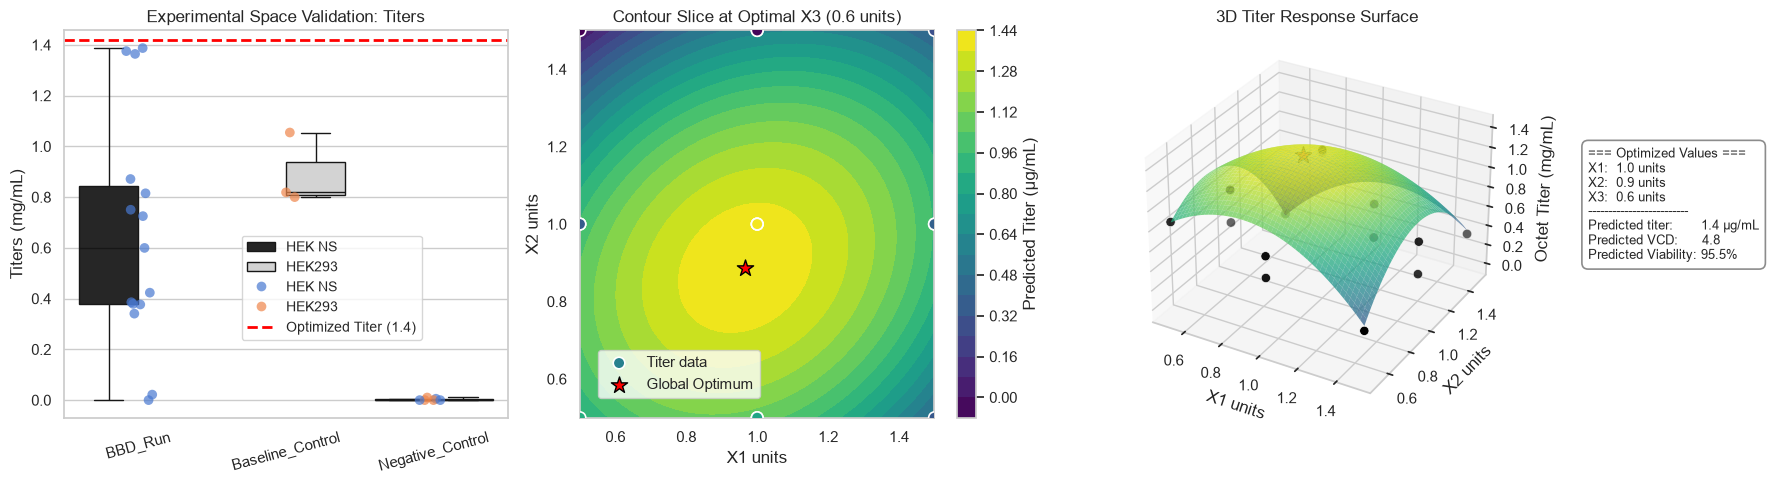

In [20]:
# ==============================================================================
# Step 6: Plotting with Optimized Values Highlighted - TITERS
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Create the figure
fig = plt.figure(figsize=(18, 5))

# Info box text formatted with optimized inputs and predicted outcomes
info_text = (
    "=== Optimized Values ===\n"
    f"X1:  {opt_natural_X1:.1f} units\n"
    f"X2:  {opt_natural_X2:.1f} units\n"
    f"X3:  {opt_natural_X3:.1f} units\n"
    "-------------------------\n"
    f"Predicted titer:       {opt_titer:.1f} µg/mL\n"
    f"Predicted VCD:      {opt_vcd:.1f}\n"
    f"Predicted Viability: {opt_viab:.1f}%"
)

# Styling for both text boxes
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", lw=1.2, alpha=0.9)

# ------------------------------------------------------------------------------
# Plot A: Scatter/Boxplot Validation for titer
# ------------------------------------------------------------------------------
ax1 = fig.add_subplot(131)
sns.boxplot(data=data, x='Type', y='mAb_Titer', hue='Cell type', ax=ax1, color='lightgray', showfliers=False)
sns.stripplot(data=data, x='Type', y='mAb_Titer', hue='Cell type', ax=ax1, jitter=True, size=7, alpha=0.7)

# Highlight the mathematically discovered optimum line
ax1.axhline(opt_titer, color='red', linestyle='--', linewidth=2, label=f'Optimized Titer ({opt_titer:.1f})')
ax1.set_title("Experimental Space Validation: Titers")
ax1.set_ylabel("Titers (mg/mL)")
ax1.set_xlabel("")
ax1.legend(loc=(0.4, 0.2), fontsize=10)
ax1.tick_params(axis='x', rotation=15)


# ------------------------------------------------------------------------------
# Generation of Grid (Dynamically sliced through the optimal Booster concentration)
# ------------------------------------------------------------------------------
x1_grid, x2_grid = np.meshgrid(np.linspace(-1, 1, 50), np.linspace(-1, 1, 50))
grid_df = pd.DataFrame({
    'X1_scaled': x1_grid.ravel(), 
    'X2_scaled': x2_grid.ravel(), 
    'X3_scaled': opt_x[2]  # Slicing dynamically at optimal Booster
})
z_pred_titer = best_titer_model.predict(grid_df).values.reshape(x1_grid.shape)

# Transform matrix grid values from scaled (-1, +1) space to natural space
x1_natural = x1_grid * 0.5 + 1.0
x2_natural = x2_grid * 0.5 + 1.0

# ------------------------------------------------------------------------------
# Plot B: 2D Contour Plot & Raw Data Overlay
# ------------------------------------------------------------------------------
ax2 = fig.add_subplot(132)
cp = ax2.contourf(x1_natural, x2_natural, z_pred_titer, levels=20, cmap='viridis')
fig.colorbar(cp, ax=ax2, label='Predicted Titer (µg/mL)')

# Overlay Raw Experimental Data Points using their real Titer concentrations
ax2.scatter(
    data_model['X1'], 
    data_model['X2'], 
    c=data_model['mAb_Titer'], 
    cmap='viridis', 
    edgecolor='white', 
    linewidth=1.2, 
    s=70, 
    zorder=4, 
    label='Titer data',
)

# Mark the peak coordinate
ax2.scatter(opt_natural_X1, opt_natural_X2, color='red', marker='*', s=150, edgecolor='black', zorder=5, label='Global Optimum')
ax2.set_title(f"Contour Slice at Optimal X3 ({opt_natural_X3:.1f} units)")
ax2.set_xlabel("X1 units")
ax2.set_ylabel("X2 units")
ax2.legend(loc=(0.05, 0.05))

# ------------------------------------------------------------------------------
# Plot C: 3D Surface Plot with Info Box Outside
# ------------------------------------------------------------------------------
ax3 = fig.add_subplot(133, projection='3d')
surf = ax3.plot_surface(x1_natural, x2_natural, z_pred_titer, cmap='viridis', edgecolor='none', alpha=0.75)

# Overlay raw titer values in 3D coordinate space
ax3.scatter(
    data_model['X1'], 
    data_model['X2'], 
    data_model['mAb_Titer'], 
    color='black', 
    s=45, 
    edgecolor='white',
    linewidth=0.5,
    depthshade=True, 
    zorder=12, 
    label='Raw Experimental Points'
)

# Mark the 3D peak coordinate
ax3.scatter(opt_natural_X1, opt_natural_X2, opt_titer, color='red', marker='*', s=150, edgecolor='black', depthshade=False, zorder=10, label='Global Optimum')
ax3.set_title("3D Titer Response Surface")
ax3.set_xlabel("X1 units")
ax3.set_ylabel("X2 units")
ax3.set_zlabel("Octet Titer (mg/mL)", rotation=90)

# ENHANCEMENT: Add the text box OUTSIDE the 3D Plot boundaries to enhance visibility
# x=1.05 puts the box comfortably to the right of the 3D axes block
ax3.text2D(1.2, 0.55, info_text, transform=ax3.transAxes, fontsize=9,
          verticalalignment='center', horizontalalignment='left', bbox=bbox_props)


plt.tight_layout()
plt.show()

## Response Surface for VCD

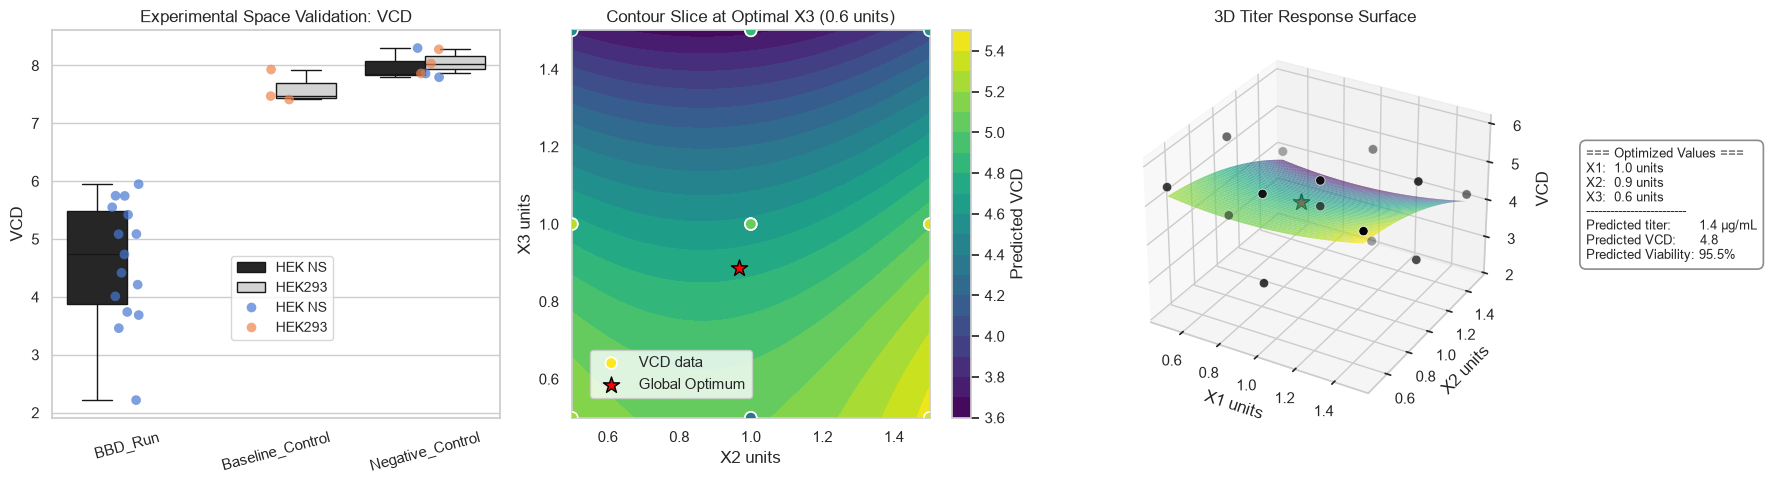

In [16]:
# ==============================================================================
# Step 6: Plotting with Optimized Values Highlighted - VCD
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Create the figure
fig = plt.figure(figsize=(18, 5))

# Info box text formatted with optimized inputs and predicted outcomes
info_text = (
    "=== Optimized Values ===\n"
    f"X1:  {opt_natural_X1:.1f} units\n"
    f"X2:  {opt_natural_X2:.1f} units\n"
    f"X3:  {opt_natural_X3:.1f} units\n"
    "-------------------------\n"
    f"Predicted titer:       {opt_titer:.1f} µg/mL\n"
    f"Predicted VCD:      {opt_vcd:.1f}\n"
    f"Predicted Viability: {opt_viab:.1f}%"
)

# Styling for both text boxes
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", lw=1.2, alpha=0.9)

# ------------------------------------------------------------------------------
# Plot A: Scatter/Boxplot Validation for titer
# ------------------------------------------------------------------------------
ax1 = fig.add_subplot(131)
sns.boxplot(data=data, x='Type', y='VCD', hue='Cell type', ax=ax1, color='lightgray', showfliers=False)
sns.stripplot(data=data, x='Type', y='VCD', hue='Cell type', ax=ax1, jitter=True, size=7, alpha=0.7)

# Highlight the mathematically discovered optimum line
#ax1.axhline(opt_titer, color='red', linestyle='--', linewidth=2, label=f'Optimized Titer ({opt_titer:.1f})')
ax1.set_title("Experimental Space Validation: VCD")
ax1.set_ylabel("VCD")
ax1.set_xlabel("")
ax1.legend(loc=(0.4, 0.2), fontsize=10)
ax1.tick_params(axis='x', rotation=15)


# ------------------------------------------------------------------------------
# Generation of Grid (Dynamically sliced through the optimal Booster concentration)
# ------------------------------------------------------------------------------
x1_grid, x2_grid = np.meshgrid(np.linspace(-1, 1, 50), np.linspace(-1, 1, 50))
grid_df = pd.DataFrame({
    'X1_scaled': x1_grid.ravel(), 
    'X2_scaled': x2_grid.ravel(), 
    'X3_scaled': opt_x[2]  # Slicing dynamically at optimal Booster
})
z_pred_VCD = best_VCD_model.predict(grid_df).values.reshape(x1_grid.shape)

# Transform matrix grid values from scaled (-1, +1) space to natural space
x1_natural = x1_grid * 0.5 + 1.0
x2_natural = x2_grid * 0.5 + 1.0

# ------------------------------------------------------------------------------
# Plot B: 2D Contour Plot & Raw Data Overlay
# ------------------------------------------------------------------------------
ax2 = fig.add_subplot(132)
cp = ax2.contourf(x1_natural, x2_natural, z_pred_VCD, levels=20, cmap='viridis')
fig.colorbar(cp, ax=ax2, label='Predicted VCD')

# Overlay Raw Experimental Data Points using their real Titer concentrations
ax2.scatter(
    data_model['X1'], 
    data_model['X2'], 
    c=data_model['VCD'], 
    cmap='viridis', 
    edgecolor='white', 
    linewidth=1.2, 
    s=70, 
    zorder=4, 
    label='VCD data',
)

# Mark the peak coordinate
ax2.scatter(opt_natural_X1, opt_natural_X2, color='red', marker='*', s=150, edgecolor='black', zorder=5, label='Global Optimum')
ax2.set_title(f"Contour Slice at Optimal X3 ({opt_natural_X3:.1f} units)")
ax2.set_xlabel("X2 units")
ax2.set_ylabel("X3 units")
ax2.legend(loc=(0.05, 0.05))

# ------------------------------------------------------------------------------
# Plot C: 3D Surface Plot with Info Box Outside
# ------------------------------------------------------------------------------
ax3 = fig.add_subplot(133, projection='3d')
surf = ax3.plot_surface(x1_natural, x2_natural, z_pred_VCD, cmap='viridis', edgecolor='none', alpha=0.75)

# Overlay raw titer values in 3D coordinate space
ax3.scatter(
    data_model['X1'], 
    data_model['X2'], 
    data_model['VCD'], 
    color='black', 
    s=45, 
    edgecolor='white',
    linewidth=0.5,
    depthshade=True, 
    zorder=12, 
    label='Raw Experimental Points'
)

# Mark the 3D peak coordinate
ax3.scatter(opt_natural_X1, opt_natural_X2, opt_vcd, color='red', marker='*', s=150, edgecolor='black', depthshade=False, zorder=10, label='Global Optimum')
ax3.set_title("3D Titer Response Surface")
ax3.set_xlabel("X1 units")
ax3.set_ylabel("X2 units")
ax3.set_zlabel("VCD", rotation=90)

# ENHANCEMENT: Add the text box OUTSIDE the 3D Plot boundaries to enhance visibility
# x=1.05 puts the box comfortably to the right of the 3D axes block
ax3.text2D(1.2, 0.55, info_text, transform=ax3.transAxes, fontsize=9,
          verticalalignment='center', horizontalalignment='left', bbox=bbox_props)


plt.tight_layout()
plt.show()

## Response Surface for Viability

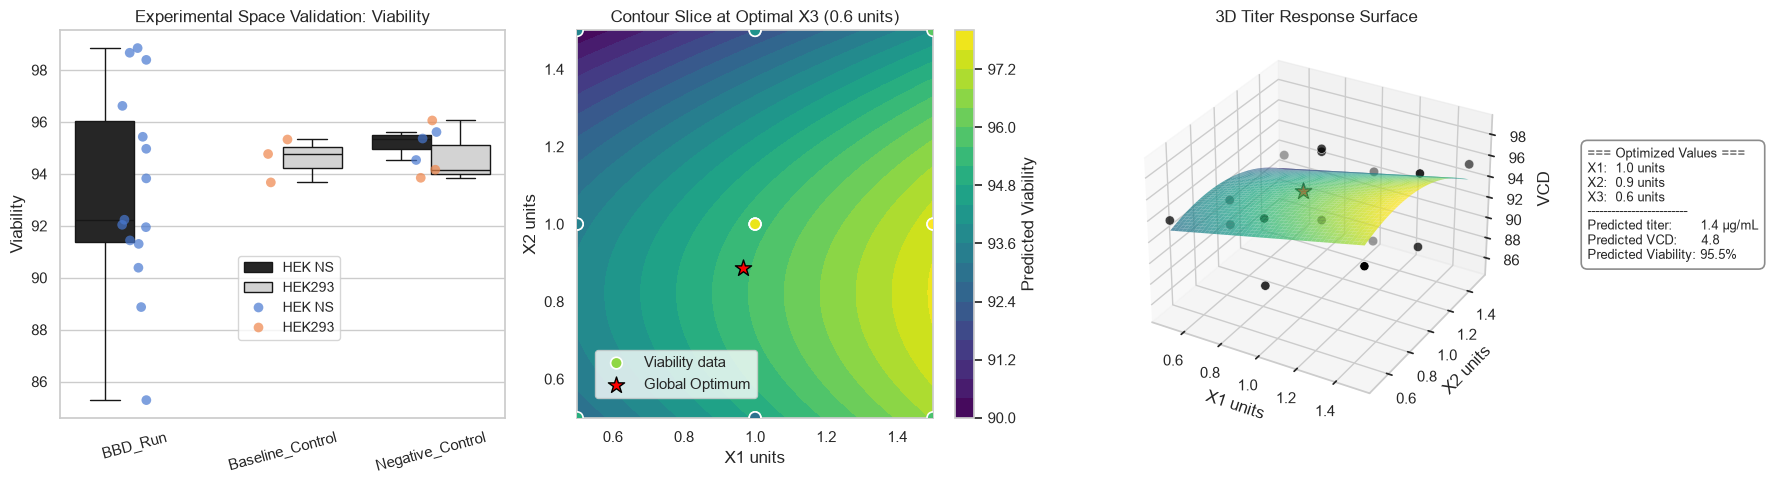

In [19]:
# ==============================================================================
# Step 6: Plotting with Optimized Values Highlighted - Viability
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Create the figure
fig = plt.figure(figsize=(18, 5))

# Info box text formatted with optimized inputs and predicted outcomes
info_text = (
    "=== Optimized Values ===\n"
    f"X1:  {opt_natural_X1:.1f} units\n"
    f"X2:  {opt_natural_X2:.1f} units\n"
    f"X3:  {opt_natural_X3:.1f} units\n"
    "-------------------------\n"
    f"Predicted titer:       {opt_titer:.1f} µg/mL\n"
    f"Predicted VCD:      {opt_vcd:.1f}\n"
    f"Predicted Viability: {opt_viab:.1f}%"
)

# Styling for both text boxes
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", lw=1.2, alpha=0.9)

# ------------------------------------------------------------------------------
# Plot A: Scatter/Boxplot Validation for titer
# ------------------------------------------------------------------------------
ax1 = fig.add_subplot(131)
sns.boxplot(data=data, x='Type', y='Viability', hue='Cell type', ax=ax1, color='lightgray', showfliers=False)
sns.stripplot(data=data, x='Type', y='Viability', hue='Cell type', ax=ax1, jitter=True, size=7, alpha=0.7)

# Highlight the mathematically discovered optimum line
#ax1.axhline(opt_titer, color='red', linestyle='--', linewidth=2, label=f'Optimized Titer ({opt_titer:.1f})')
ax1.set_title("Experimental Space Validation: Viability")
ax1.set_ylabel("Viability")
ax1.set_xlabel("")
ax1.legend(loc=(0.4, 0.2), fontsize=10)
ax1.tick_params(axis='x', rotation=15)


# ------------------------------------------------------------------------------
# Generation of Grid (Dynamically sliced through the optimal Booster concentration)
# ------------------------------------------------------------------------------
x1_grid, x2_grid = np.meshgrid(np.linspace(-1, 1, 50), np.linspace(-1, 1, 50))
grid_df = pd.DataFrame({
    'X1_scaled': x1_grid.ravel(), 
    'X2_scaled': x2_grid.ravel(), 
    'X3_scaled': opt_x[2]  # Slicing dynamically at optimal Booster
})
z_pred_viability = best_viability_model.predict(grid_df).values.reshape(x1_grid.shape)

# Transform matrix grid values from scaled (-1, +1) space to natural space
x1_natural = x1_grid * 0.5 + 1.0
x2_natural = x2_grid * 0.5 + 1.0

# ------------------------------------------------------------------------------
# Plot B: 2D Contour Plot & Raw Data Overlay
# ------------------------------------------------------------------------------
ax2 = fig.add_subplot(132)
cp = ax2.contourf(x1_natural, x2_natural, z_pred_viability, levels=20, cmap='viridis')
fig.colorbar(cp, ax=ax2, label='Predicted Viability')

# Overlay Raw Experimental Data Points using their real Titer concentrations
ax2.scatter(
    data_model['X1'], 
    data_model['X2'], 
    c=data_model['Viability'], 
    cmap='viridis', 
    edgecolor='white', 
    linewidth=1.2, 
    s=70, 
    zorder=4, 
    label='Viability data',
)

# Mark the peak coordinate
ax2.scatter(opt_natural_X1, opt_natural_X2, color='red', marker='*', s=150, edgecolor='black', zorder=5, label='Global Optimum')
ax2.set_title(f"Contour Slice at Optimal X3 ({opt_natural_X3:.1f} units)")
ax2.set_xlabel("X1 units")
ax2.set_ylabel("X2 units")
ax2.legend(loc=(0.05, 0.05))

# ------------------------------------------------------------------------------
# Plot C: 3D Surface Plot with Info Box Outside
# ------------------------------------------------------------------------------
ax3 = fig.add_subplot(133, projection='3d')
surf = ax3.plot_surface(x1_natural, x2_natural, z_pred_viability, cmap='viridis', edgecolor='none', alpha=0.75)

# Overlay raw titer values in 3D coordinate space
ax3.scatter(
    data_model['X1'], 
    data_model['X2'], 
    data_model['Viability'], 
    color='black', 
    s=45, 
    edgecolor='white',
    linewidth=0.5,
    depthshade=True, 
    zorder=12, 
    label='Raw Experimental Points'
)

# Mark the 3D peak coordinate
ax3.scatter(opt_natural_X1, opt_natural_X2, opt_viab, color='red', marker='*', s=150, edgecolor='black', depthshade=False, zorder=10, label='Global Optimum')
ax3.set_title("3D Titer Response Surface")
ax3.set_xlabel("X1 units")
ax3.set_ylabel("X2 units")
ax3.set_zlabel("VCD", rotation=90)

# ENHANCEMENT: Add the text box OUTSIDE the 3D Plot boundaries to enhance visibility
# x=1.05 puts the box comfortably to the right of the 3D axes block
ax3.text2D(1.2, 0.55, info_text, transform=ax3.transAxes, fontsize=9,
          verticalalignment='center', horizontalalignment='left', bbox=bbox_props)


plt.tight_layout()
plt.show()